In [1]:
# Figure font sizing for journal submission.
# Raise FONT_SCALE (e.g. to 1.4) and re-run to enlarge ALL text uniformly
# across every figure in this notebook. FONT_SCALE = 1.0 reproduces the
# original figures exactly (10.0 is the matplotlib default font.size, and the
# title/tick/legend sizes are relative to it, so they scale automatically).
import matplotlib as mpl

FONT_SCALE = 1.4
mpl.rcParams["font.size"] = 10.0 * FONT_SCALE


In [2]:
# import axelrod as axl
import matplotlib
import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import json
# import dask.dataframe as dd

import pathlib
import re

# import sympy as sym

# from itertools import combinations
# import tqdm
# from collections import defaultdict

# from matplotlib.ticker import LinearLocator

In [3]:
with open("./data/original_tournament_with_probabilistic_end/fortran_characteristics.json", "r") as f:
    characteristics = json.load(f)

In [4]:
second_tournament_strategies = [
    name for name in characteristics.keys()
    if characteristics[name]["original_rank"] is not None
]

## Helping Functions

In [5]:
def get_turns(filename):
    """
    Read the number of turns if included in the file name
    """
    match = re.search("[0-9]+(?=(_turns))", str(filename))
    return int(match.group(0))

def get_repetitions(filename):
    """
    Read the number of repetitions if included in the file name
    """
    match = re.search("[0-9]+(?=(_repetitions))", str(filename))
    return int(match.group(0))

def read_tournament_repetitions(files, player_names=None):
    """
    Read the scores from a collection of gz files 
    representing repetitions of tournaments.
    """
    number_of_opponents = len(player_names) - 1
    dfs = []
    for gz_path in files:
        dfs.append(pd.read_csv(str(gz_path), header=None).iloc[:,0:number_of_opponents + 1])
        
        turns = get_turns(gz_path)
        
        dfs[-1] /= turns * (number_of_opponents)  # Scale all metrics
        dfs[-1].columns = player_names
        
    df = pd.concat(dfs, ignore_index=True)
    return df

def read_payoff_matrix(files):
    arrays = []
    turns = []
    repetitions = 0
    for gz_path in files:
        repetitions += get_repetitions(gz_path)
        arrays.append(np.array(pd.read_csv(str(gz_path), header=None)))  # Read through pd to deal with float conversion
        turns.append(get_turns(str(gz_path)))
    payoff_matrix = sum(array * turn for turn, array in zip(turns, arrays)) / sum(turns)

    return payoff_matrix, repetitions


def get_matching_lengths_file(scores_path):
    return pathlib.Path(
        str(scores_path).replace(
            "_scores.gz",
            "_match_lengths_per_tournament.gz"
        )
    )

def read_probabilistic_tournament_repetitions(files, player_names):
    dfs = []

    number_of_opponents = len(player_names) - 1

    for scores_path in files:
        scores_path = pathlib.Path(scores_path)
        lengths_path = get_matching_lengths_file(scores_path)

        scores = pd.read_csv(scores_path, header=None)
        lengths = pd.read_csv(lengths_path, header=None)

        scores = scores.iloc[:, :len(player_names)]
        lengths = lengths.iloc[:, :len(player_names)]

        normalised_scores = scores / (lengths * number_of_opponents)

        normalised_scores.columns = player_names

        dfs.append(normalised_scores)

    return pd.concat(dfs, ignore_index=True)


def get_matching_lengths_file(scores_path):
    return pathlib.Path(
        str(scores_path).replace(
            "_scores.gz",
            "_match_lengths_per_tournament.gz"
        )
    )


def read_probabilistic_payoff_matrix(files):
    weighted_arrays = []
    length_arrays = []

    repetitions = 0

    for scores_path in files:

        repetitions += get_repetitions(scores_path)

        scores = np.array(
            pd.read_csv(scores_path, header=None)
        )

        lengths_path = get_matching_lengths_file(scores_path)

        lengths = np.array(
            pd.read_csv(lengths_path, header=None)
        )

        weighted_arrays.append(scores * lengths)
        length_arrays.append(lengths)

    payoff_matrix = (
        np.sum(weighted_arrays, axis=0)
        / np.sum(length_arrays, axis=0)
    )

    return payoff_matrix, repetitions

## Data

In [6]:
original_tournament_data_path = pathlib.Path("./data/original_tournament/")
original_tournament_scores = read_tournament_repetitions(
                                   files=original_tournament_data_path.glob("*scores.gz"), 
                                   player_names=second_tournament_strategies)

In [7]:
original_tournament_payoff_matrix, original_repetitions = read_payoff_matrix(original_tournament_data_path.glob("*payoff_matrix.gz"))

In [8]:
scores = pd.DataFrame(original_tournament_payoff_matrix, 
                      second_tournament_strategies)
scores.columns = scores.index

In [9]:
scores["Scores"] = np.mean(original_tournament_payoff_matrix, axis=1)
scores["Reproduced Rank"] = scores["Scores"].rank(ascending=False).astype(int)
scores["Original Rank"] =  [characteristics[name]["original_rank"] for name in scores.index]
scores["Author"] =  [characteristics[name]["author"] for name in scores.index]
scores.sort_values("Original Rank", inplace=True)

In [10]:
probend_tournament_data_path = pathlib.Path("./data/original_tournament_with_probabilistic_end/")
probend_tournament_scores = read_probabilistic_tournament_repetitions(
                                   files=probend_tournament_data_path.glob("*scores.gz"), 
                                   player_names=second_tournament_strategies)

In [11]:
probend_tournament_payoff_matrix, _ = read_probabilistic_payoff_matrix(probend_tournament_data_path.glob("*payoff_matrix.gz"))

In [12]:
list(probend_tournament_data_path.glob("*scores.gz"))

[PosixPath('data/original_tournament_with_probabilistic_end/original_0.006622516556291391_prob_end_1000_repetitions_4_seed_scores.gz'),
 PosixPath('data/original_tournament_with_probabilistic_end/original_0.006622516556291391_prob_end_1000_repetitions_5_seed_scores.gz'),
 PosixPath('data/original_tournament_with_probabilistic_end/original_0.006622516556291391_prob_end_1000_repetitions_7_seed_scores.gz'),
 PosixPath('data/original_tournament_with_probabilistic_end/original_0.006622516556291391_prob_end_1000_repetitions_6_seed_scores.gz'),
 PosixPath('data/original_tournament_with_probabilistic_end/original_0.006622516556291391_prob_end_1000_repetitions_1_seed_scores.gz')]

In [13]:
probend = pd.DataFrame(probend_tournament_payoff_matrix, 
                       second_tournament_strategies)
probend.columns = probend.index

probend["Scores"] = np.mean(probend_tournament_payoff_matrix, axis=1)
probend["Reproduced Rank"] = probend["Scores"].rank(ascending=False).astype(int)
probend["Original Rank"] =  [characteristics[name]["original_rank"] for name in probend.index]
probend.sort_values("Original Rank", inplace=True)

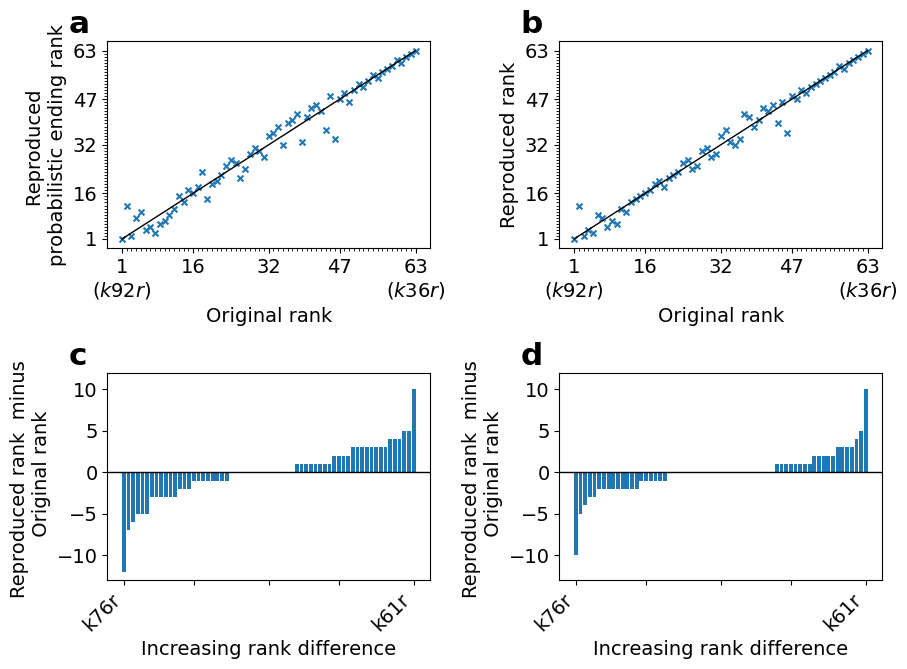

In [14]:
fig, axes = plt.subplot_mosaic(
    """
    AB
    CD
    """,
    figsize=(10, 7),
    gridspec_kw={"wspace": 0.4, "hspace": 0.6},
)

n = len(scores.index)
rank_ticks = [1, 16, 32, 47, 63]
rank_labels = [
    "1\n" + r"$(\mathit{k92r})$",
    "16",
    "32",
    "47",
    "63\n" + r"$(\mathit{k36r})$",
]

# ------------------------------------------------------------------
# Panels A and B
# ------------------------------------------------------------------

for letter in "AB":

    ax = axes[letter]

    ax.set_xticks(rank_ticks)
    ax.set_xticklabels(rank_labels)

    ax.set_yticks(rank_ticks)

    ax.set_xticks(range(1, n + 1), minor=True)
    ax.set_yticks(range(1, n + 1), minor=True)

    ax.plot([1, n], [1, n], color="black", linewidth=1)

axes["A"].scatter(
    scores["Original Rank"],
    probend["Reproduced Rank"],
    s=18,
    marker="x",
    color="tab:blue",
)

axes["A"].set_xlabel("Original rank")
axes["A"].set_ylabel("Reproduced \nprobabilistic ending rank")

axes["B"].scatter(
    scores["Original Rank"],
    scores["Reproduced Rank"],
    s=18,
    marker="x",
    color="tab:blue",
)

axes["B"].set_xlabel("Original rank")
axes["B"].set_ylabel("Reproduced rank")


# ------------------------------------------------------------------
# Panel C
# Original rank - probabilistic ending rank
# ------------------------------------------------------------------

diff_c = (
    probend["Reproduced Rank"]
    - scores["Original Rank"]
).rename("diff")

diff_c = diff_c.sort_values()

x = range(1, n + 1)

axes["C"].bar(x, diff_c.values)

axes["C"].axhline(0, linewidth=1, color="black")

max_abs_c = max(abs(diff_c.min()), abs(diff_c.max()))

axes["C"].set_ylim(-1.1 * max_abs_c, 1.1 * max_abs_c)

axes["C"].set_xticks(rank_ticks)
axes["C"].set_xticklabels([
    diff_c.index[0],
    "",
    "",
    "",
    diff_c.index[-1],
], rotation=45, ha="right")

axes["C"].set_xlabel("Increasing rank difference")
axes["C"].set_ylabel("Reproduced rank  minus \n Original rank")


# ------------------------------------------------------------------
# Panel D
# Reproduced rank - probabilistic ending rank
# ------------------------------------------------------------------

diff_d = (
    scores["Reproduced Rank"] - 
    scores["Original Rank"]
).rename("diff")

diff_d = diff_d.sort_values()

axes["D"].bar(x, diff_d.values)

axes["D"].axhline(0, linewidth=1, color="black")

max_abs_d = max(abs(diff_d.min()), abs(diff_d.max()))

axes["D"].set_ylim(-1.1 * max_abs_d, 1.1 * max_abs_d)

axes["D"].set_xticks(rank_ticks)
axes["D"].set_xticklabels([
    diff_d.index[0],
    "",
    "",
    "",
    diff_d.index[-1],
], rotation=45, ha="right")

axes["D"].set_xlabel("Increasing rank difference")
axes["D"].set_ylabel("Reproduced rank  minus \n Original rank")


# ------------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------------

for key in "CD":
    axes[key].set_ylim(-13, 12)
    
for key, label in zip("ABCD", "abcd"):

    axes[key].text(
        -0.12,
        1.15,
        label,
        transform=axes[key].transAxes,
        fontsize=16 * FONT_SCALE,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.savefig(
    "../paper/assets/probalistic_ending_tournament.pdf",
    bbox_inches="tight"
)

In [15]:
(scores["Reproduced Rank"] - scores["Original Rank"]).sort_values()

k76r   -10
k87r    -5
k32r    -4
k40r    -3
k75r    -3
        ..
k56r     3
k73r     3
k85r     4
k37r     5
k61r    10
Length: 63, dtype: int64

In [16]:
(probend["Reproduced Rank"] - scores["Original Rank"]).sort_values()

k76r   -12
k87r    -7
k43r    -6
k78r    -5
k79r    -5
        ..
k49r     4
k38r     4
k51r     5
k44r     5
k61r    10
Length: 63, dtype: int64